# 📓 Linear Regression from Scratch

### 🎯 Objective
- Implement a linear regression model using gradient descent.
- Derive the gradient updates, write a scikit-learn-like class, and evaluate using synthetic data.
- Compare the result of the same with library code output
- Use R2-Score and Mean Absolute Percentage error as Performance metric on test data

## 📊 Generate Synthetic Data

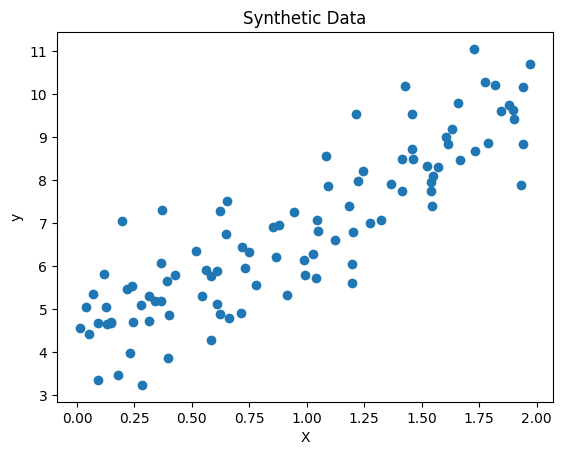

In [5]:

import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic data
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Plot
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Data")
plt.show()


## Do Train-Test Split (75%-25%)

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Do the Linear Regression with Scikit-Learn Library

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_percentage_error
model = LinearRegression()
model.fit(x_train,y_train)


y_pred = model.predict(x_test)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

mape = mean_absolute_percentage_error(y_test,y_pred)
print("MAPE:", mape)


R2 Score: 0.8072059636181392
MAPE: 0.0801676571140541


## Do Ridge and Lasso Regression and Compare the evaluation metrics in a table

In [39]:
import pandas as pd

#Ridge
from sklearn.linear_model import Ridge,Lasso
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train, y_train)

ridge_y_pred = ridge_model.predict(x_test)
ridge_r2 = r2_score(y_test, ridge_y_pred)

ridge_mape = mean_absolute_percentage_error(y_test, ridge_y_pred)



#Lasso
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(x_train, y_train)

lasso_y_pred = lasso_model.predict(x_test)
lasso_r2 = r2_score(y_test, lasso_y_pred)
lasso_mape = mean_absolute_percentage_error(y_test, lasso_y_pred)


result_df = pd.DataFrame(columns=['Model','R2 Score','MAPE'])
result_df.loc[len(result_df)] = ['Ridge Regression',ridge_r2,ridge_mape]
result_df.loc[len(result_df)] = ['Lasso Regression',lasso_r2,lasso_mape]
result_df

,Model,R2 Score,MAPE
0,Ridge Regression,0.809001,0.076362
1,Lasso Regression,-0.023431,0.223348


## Custom Implementation

## 🧮 Derive the Gradient Updates
Use the chain rule to derive the gradients of the loss function (Mean Square Error):

$$ \text{Loss} = \frac{1}{N} \sum_{i=1}^{N} (y_i - (mx_i + c))^2 $$

Derive:
- ∂Loss/∂m
- ∂Loss/∂c

Write the derivation here/add screenshot of your derivation here:


Mean Squared Error Loss
Loss:

$$
\text{Loss} = \frac{1}{N} \sum_{i=1}^{N} (y_i - (mx_i + c))^2
$$

---

Define prediction
$$
\hat{y}_i = mx_i + c
$$

$$
e_i = y_i - \hat{y}i
$$

$$
\text{Loss} = \frac{1}{N}\sum{i=1}^{N} ei^2
$$

---

Gradient w.r.t m
Chain rule:

$$
\frac{\partial \text{Loss}}{\partial m}
=
\frac{1}{N}\sum{i=1}^{N}
\frac{\partial (e_i^2)}{\partial m}
$$

$$
\frac{\partial (e_i^2)}{\partial m}
=
2 e_i \cdot \frac{\partial e_i}{\partial m}
$$

Since

$$
e_i = y_i - (mx_i + c)
$$

$$
\frac{\partial e_i}{\partial m} = -xi
$$

Therefore

$$
\frac{\partial \text{Loss}}{\partial m}
=
-\frac{2}{N}\sum{i=1}^{N}
x_i (y_i - (mxi + c))
$$

---

Gradient w.r.t c
$$
\frac{\partial \text{Loss}}{\partial c}
=
\frac{1}{N}\sum{i=1}^{N}
\frac{\partial (e_i^2)}{\partial c}
$$

$$
\frac{\partial (e_i^2)}{\partial c}
=
2 ei \cdot (-1)
$$

Therefore

$$
\frac{\partial \text{Loss}}{\partial c}
=
-\frac{2}{N}\sum{i=1}^{N}
(y_i - (mx_i + c))
$$

## 🧠 Custom Linear Regression Class

In [41]:
import numpy as np

class MyLinearRegression:
    def __init__(self):
        self.m = None  # Slope
        self.c = None  # Intercept
        self.loss_history = []

    def fit(self, X, y, lr=0.01, n_iters=1000):
        # Ensure X is 2D and y is 2D
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        n_samples = X.shape[0]

        # Initialize parameters
        # Using X.shape[1] for multiple features, though our current X is (100,1)
        self.m = np.zeros(X.shape[1]) if X.shape[1] > 1 else 0.0
        self.c = 0.0

        self.loss_history = []

        # Gradient Descent
        for _ in range(n_iters):
            y_pred = np.dot(X, self.m) + self.c

            # Calculate gradients
            dm = (-2/n_samples) * np.dot(X.T, (y - y_pred))
            dc = (-2/n_samples) * np.sum(y - y_pred)

            # Update parameters
            self.m = self.m - lr * dm
            self.c = self.c - lr * dc

            # Calculate and store loss (Mean Squared Error)
            loss = np.mean((y - y_pred)**2)
            self.loss_history.append(loss)

    def predict(self, X):
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        if self.m is None or self.c is None:
            raise Exception("Model has not been trained yet. Call fit() first.")
        return np.dot(X, self.m) + self.c

    def fit_transform(self, X, y, lr=0.01, n_iters=1000):
        self.fit(X, y, lr, n_iters)
        return self.predict(X)

## 🔁 Train the Model and Visualize the Fit

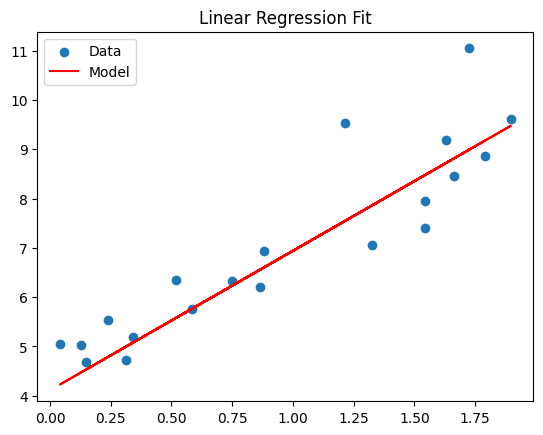

Learned coefficients (m, c): [[2.82759406]] 4.111198642356238


In [43]:
model = MyLinearRegression()
model.fit(x_train, y_train, lr=0.1, n_iters=100)

# Predictions
y_pred = model.predict(x_test)

# Plot
plt.scatter(x_test, y_test, label="Data")
plt.plot(x_test, y_pred, color="red", label="Model")
plt.legend()
plt.title("Linear Regression Fit")
plt.show()

# Print coefficients
print("Learned coefficients (m, c):", model.m, model.c)

## 📉 Plot the Loss Curve

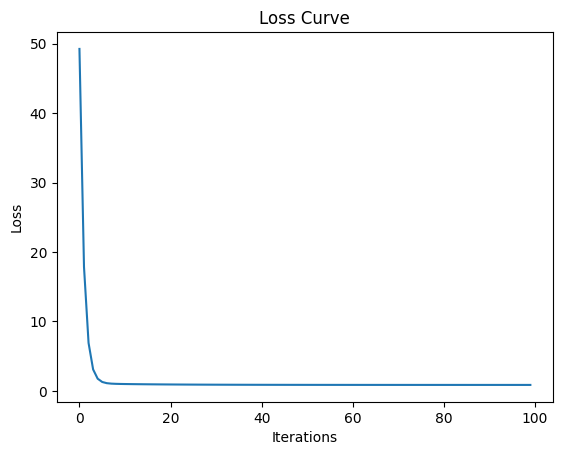

In [47]:
plt.plot(model.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()



## 🌟 Bonus Task: Stochastic Gradient Descent
Implement a class `MyLinearRegressionSGD` that uses one training sample per iteration to update weights.

In [55]:
import random
import numpy as np

class MyLinearRegressionSGD:
    def __init__(self, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs
        self.w = 0
        self.b = 0
        self.loss_history = [] # Add loss history

    def fit(self, X, y):
        n = len(X)
        self.loss_history = [] # Reset loss history for each fit
        for _ in range(self.epochs):
            i = random.randint(0, n - 1)
            y_pred = self.w * X[i] + self.b

            # Calculate gradients
            dw = -2 * X[i] * (y[i] - y_pred)
            db = -2 * (y[i] - y_pred)

            # Update parameters
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # Calculate and store loss (Mean Squared Error) for the entire dataset
            # This is a bit computationally intensive for every single SGD step,
            # but common for plotting a smooth curve representative of overall performance.
            # For true SGD loss, one would typically plot the loss per batch/sample processed.
            full_y_pred = self.w * X + self.b
            loss = np.mean((y - full_y_pred)**2)
            self.loss_history.append(loss)

    def predict(self, X):
        return [self.w * x + self.b for x in X]

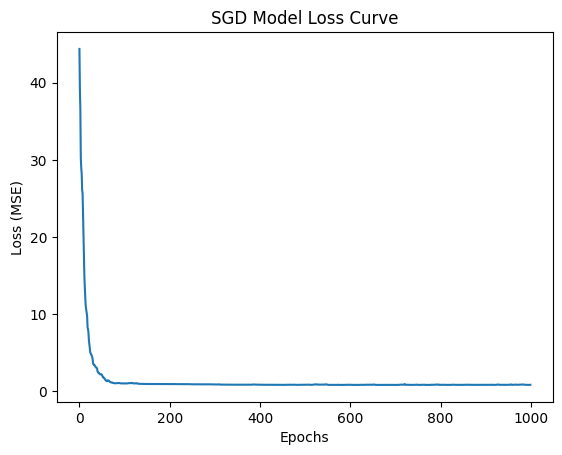

In [56]:
import matplotlib.pyplot as plt

# Instantiate and train the SGD model with the modified class
sgd_model = MyLinearRegressionSGD(lr=0.01, epochs=1000)
sgd_model.fit(x_train.flatten(), y_train.flatten())

# Plot the loss curve
plt.plot(sgd_model.loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("SGD Model Loss Curve")
plt.show()

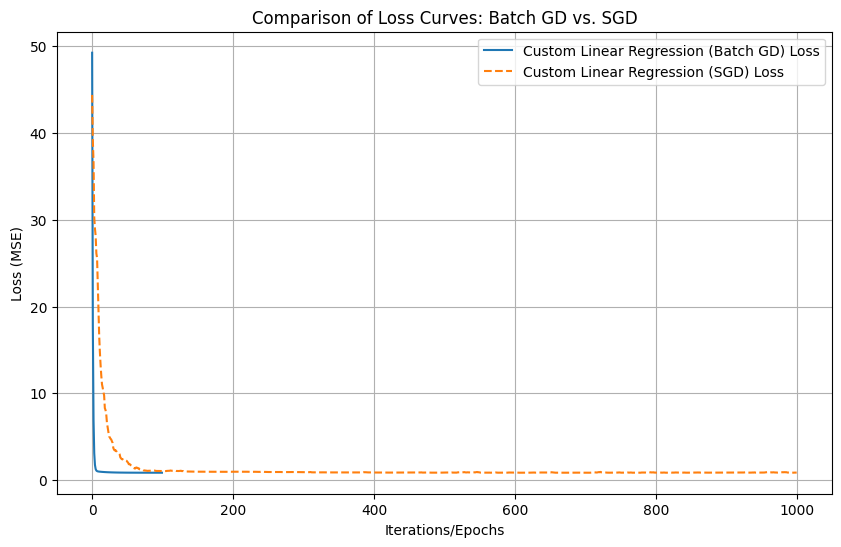

In [57]:
import matplotlib.pyplot as plt

# Ensure both models are trained and have loss history
# (MyLinearRegression is trained in iykzHnIWS2eW, MyLinearRegressionSGD in dP-YX19ZcJXS)
# If you've restarted the kernel, run those cells first.

plt.figure(figsize=(10, 6))

# Plot Loss Curve for Custom MyLinearRegression (Batch Gradient Descent)
if hasattr(model, 'loss_history') and model.loss_history:
    plt.plot(model.loss_history, label='Custom Linear Regression (Batch GD) Loss')
else:
    print("MyLinearRegression loss history not available. Please ensure it's trained.")

# Plot Loss Curve for Custom MyLinearRegressionSGD
if hasattr(sgd_model, 'loss_history') and sgd_model.loss_history:
    plt.plot(sgd_model.loss_history, label='Custom Linear Regression (SGD) Loss', linestyle='--')
else:
    print("MyLinearRegressionSGD loss history not available. Please ensure it's trained.")

plt.xlabel("Iterations/Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Comparison of Loss Curves: Batch GD vs. SGD")
plt.legend()
plt.grid(True)
plt.show()

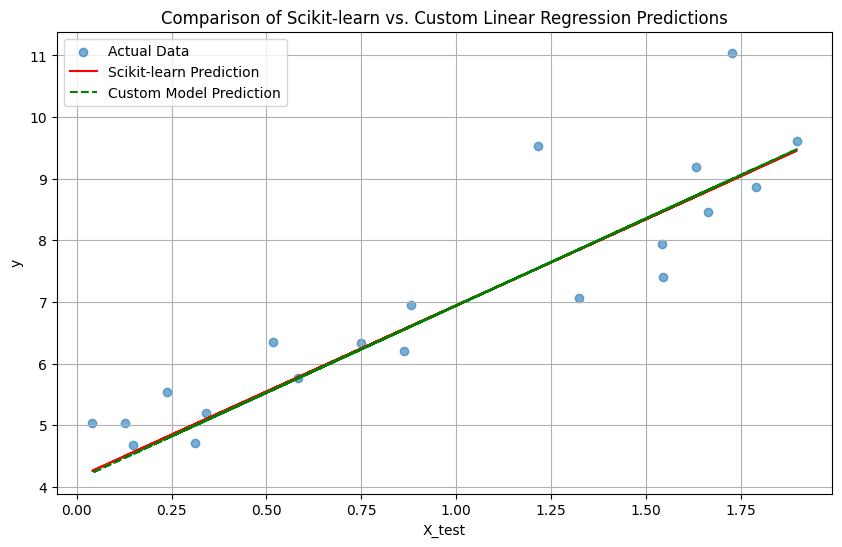

In [53]:
import matplotlib.pyplot as plt

# Re-instantiate and train scikit-learn Linear Regression model
sklearn_model = LinearRegression()
sklearn_model.fit(x_train, y_train)
sklearn_y_pred = sklearn_model.predict(x_test)

# Get predictions from the custom Linear Regression model (already trained in iykzHnIWS2eW)
# The 'model' variable currently holds the MyLinearRegression instance
custom_y_pred = model.predict(x_test)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.scatter(x_test, y_test, label='Actual Data', alpha=0.6)
plt.plot(x_test, sklearn_y_pred, color='red', linestyle='-', label='Scikit-learn Prediction')
plt.plot(x_test, custom_y_pred, color='green', linestyle='--', label='Custom Model Prediction')

plt.xlabel('X_test')
plt.ylabel('y')
plt.title('Comparison of Scikit-learn vs. Custom Linear Regression Predictions')
plt.legend()
plt.grid(True)
plt.show()

## ✅ Checklist
- [ ] Did linear regression using scikit-learn API
- [ ] Did Ridge and Lasso regression and compiled the result (R2 and MAPE) as a table
- [ ] Derived gradients using chain rule
- [ ] Implemented custom Linear Regression class
- [ ] Trained using gradient descent
- [ ] Visualized predictions and loss
- [ ] Implemented stochastic gradient descent (bonus)
- [ ] Visualized predictions and loss for stochastic gradient descent (bonus)
- [ ] Visualize the prediction result of Library version and custom version